In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()

model = ChatAnthropic(model="claude-haiku-4-5-20251001")

In [3]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [4]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate an  detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [5]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    # call llm gen content
    prompt = f'Write a detailed blog on the title - {title} using the following outline \n {outline}'
    content = model.invoke(prompt).content

    # update state
    state['content'] = content

    return state

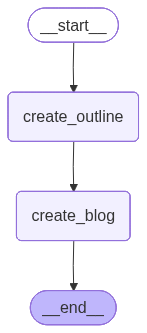

In [6]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

graph.compile()

In [7]:
workflow = graph.compile()

In [8]:
initial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': "# Rise of AI in India - Detailed Blog Outline\n\n## I. Introduction\n- A. Hook: India's AI revolution statistics\n- B. Context: Global AI landscape vs. India's position\n- C. Thesis statement: How India is becoming an AI powerhouse\n- D. Brief overview of what the blog will cover\n\n---\n\n## II. Current State of AI in India\n- A. Market size and growth projections\n  - 1. Current valuation (2024)\n  - 2. Expected CAGR through 2030\n- B. India's rank in global AI development\n- C. Key metrics and benchmarks\n- D. Government recognition and initiatives\n\n---\n\n## III. Government Support and Policy Framework\n- A. National AI Strategy (2018)\n  - 1. Key objectives and goals\n  - 2. Five pillars of the strategy\n- B. AI for All initiative\n- C. Data Protection Bill and regulations\n- D. Funding and grants for AI startups\n- E. National Center for AI establishment\n- F. Industry 4.0 and Digital India alignment\n\n---\n\n## IV. Key Sectors Driv

In [9]:
final_state['outline']

"# Rise of AI in India - Detailed Blog Outline\n\n## I. Introduction\n- A. Hook: India's AI revolution statistics\n- B. Context: Global AI landscape vs. India's position\n- C. Thesis statement: How India is becoming an AI powerhouse\n- D. Brief overview of what the blog will cover\n\n---\n\n## II. Current State of AI in India\n- A. Market size and growth projections\n  - 1. Current valuation (2024)\n  - 2. Expected CAGR through 2030\n- B. India's rank in global AI development\n- C. Key metrics and benchmarks\n- D. Government recognition and initiatives\n\n---\n\n## III. Government Support and Policy Framework\n- A. National AI Strategy (2018)\n  - 1. Key objectives and goals\n  - 2. Five pillars of the strategy\n- B. AI for All initiative\n- C. Data Protection Bill and regulations\n- D. Funding and grants for AI startups\n- E. National Center for AI establishment\n- F. Industry 4.0 and Digital India alignment\n\n---\n\n## IV. Key Sectors Driving AI Adoption\n- A. Information Technology

In [10]:
final_state['content']

'# Rise of AI in India: From Emerging Market to Global AI Powerhouse\n\n## Introduction\n\nIndia stands at the precipice of an artificial intelligence revolution. With a projected AI market valued at **$5.2 billion in 2024** and expected to grow at a **CAGR of 38.1% through 2030**, India is rapidly transforming from a service-driven economy to an innovation hub. According to recent reports, India is home to over **1,400+ AI startups**, making it the third-largest AI startup ecosystem globally—behind only the United States and China.\n\nThe global AI landscape has been dominated by Western nations, but India\'s unique combination of technical talent, massive data availability, cost-effective solutions, and government support is reshaping the competitive dynamics. With over **1 million developers** working on AI projects and a demographic dividend of young innovators, India isn\'t just adopting AI—it\'s reimagining how AI can serve a population of 1.4 billion people and emerging markets 

In [11]:
# Home Work
# START -> create_outline -> create_blog -> evaluate_blog -> END